# Online Shoppers Purchasing

Задача: 

Будем пытаться предсказать совершение покупки пользователем во время его сессии на сайте некоторого интернет-магазина.

Признаки:

0.   Administrative           12330 non-null  int64  
1.   Administrative_Duration  12330 non-null  float64
2.   Informational            12330 non-null  int64  
3.   Informational_Duration   12330 non-null  float64
4.   ProductRelated           12330 non-null  int64  
5.   ProductRelated_Duration  12330 non-null  float64
6.   BounceRates              12330 non-null  float64
7.   ExitRates                12330 non-null  float64
8.   PageValues               12330 non-null  float64
9.   SpecialDay               12330 non-null  float64
10.  Month                    12330 non-null  object 
11.  OperatingSystems         12330 non-null  int64  
12.  Browser                  12330 non-null  int64  
13.  Region                   12330 non-null  int64  
14.  TrafficType              12330 non-null  int64  
15.  VisitorType              12330 non-null  object 
16.  Weekend                  12330 non-null  bool   
17.  Revenue (Целевой признак)

Импорт библиотек:

In [24]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn.ensemble import RandomForestClassifier
from sklearn import tree # деревья решений
from sklearn import metrics # метрики
from sklearn import model_selection # методы разделения и валидации
from sklearn import ensemble # ансамбли

plt.style.use('seaborn-v0_8') #стиль отрисовки seaborn
%matplotlib inline

Основные данные:

In [25]:
shoppers_data = pd.read_csv('Data/online_shoppers_intention.csv')
display(shoppers_data.info())
display(shoppers_data.head())
display(shoppers_data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

None

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


(12330, 18)

В нашей таблице содержится информация о более чем 12 тысячах сессий на сайте интернет-магазина. Каждая сессия описывается 18 признаками.

Заранее удостоверимся в отсутствии пропусков:

In [26]:
display(shoppers_data.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Пропусков нет. Это хорошо.

Закодируем категориальные признаки с помошщью get_dummies()

In [27]:
dummy_data = pd.get_dummies(shoppers_data)
display(dummy_data.shape)

(12330, 29)

Теперь, когда необходимые преобразования выполнены, мы можем говорить о построении модели.

Итак, нам необходимо предсказать целевую переменную Revenue — признак покупки. Целевой признак является бинарным категориальным, то есть мы решаем задачу бинарной классификации. В первую очередь посмотрим на соотношение классов в данных:

Sessions without purchase : 84.53%
Sessions with purchase: 15.47%


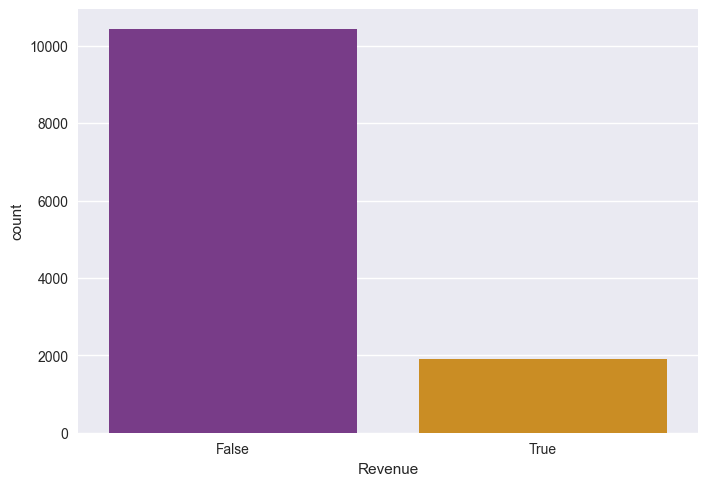

In [28]:
sns.countplot(x='Revenue', data=dummy_data, hue='Revenue', palette='CMRmap', legend=False)
class_percent = dummy_data['Revenue'].value_counts(normalize=True) * 100

print('Sessions without purchase : {:.2f}%'.format(class_percent.iloc[0]))
print('Sessions with purchase: {:.2f}%'.format(class_percent.iloc[1]))

Не вооруженным взглядом видно, что выборка не сбалансированна. Из 12330 сессий покупкой товара завершаются лишь 15.47 %. Мы знаем, что такое соотношение классов заставляет нас смотреть на метрики для каждого из классов отдельно. 

Условимся, что лучшей будет считаться та модель, у которой значение метрики $F_1$ для пользователей, совершивших покупку, будет наибольшим.

Разделим набор данных на матрицу наблюдений X и вектор ответов y:

In [29]:
X = dummy_data.drop('Revenue', axis=1)
y = dummy_data['Revenue'] #<---- Целевой признак

Мы будем производить контроль качества наших моделей:

- Разделим выборку на тренировочную и тестовую.
- Будем проводить кросс-валидацию на тренировочной выборке (то есть будем делить её на тренировочные и валидационные фолды и считать среднее значение метрики по фолдам).

Итого мы будем использовать три показателя:

- значение метрики на тренировочных и валидационных фолдах кросс-валидации (по ним мы будем отслеживать переобучение модели и подбирать внешние параметры);
- значение метрики на отложенной тестовой выборке (оно будет нашим контрольным показателем).

Другими словами, мы будем сочетать hold-оut- и k-fold-подходы к валидации.

Разделим выборку на тренировочную и тестовую в соотношении 80/20. Используем разбиение, стратифицированное по целевому признаку. В качестве значения параметра random_state возьмем число 42.

In [30]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, 
    y,
    stratify=y, 
    test_size=0.2, 
    random_state=42
)

# Подсчет количества сессий
train_sessions = len(X_train)  # Количество наблюдений в тренировочной выборке
test_sessions = len(X_test)    # Количество наблюдений в тестовой выборке

print(f"Количество сессий в тренировочной выборке: {train_sessions}")
print(f"Количество сессий в тестовой выборке: {test_sessions}")

Количество сессий в тренировочной выборке: 9864
Количество сессий в тестовой выборке: 2466


Для решения данной задачи попробуем использовать случайный лес (Random Forest). Создадим модель случайного леса, в качестве random_state возьмем 42. Остальные параметры оставим по умолчанию.

Далее оценим качество модели с помощью кросс-валидации используя валидатор StratifiedKfold (перемешивать выборку не будем) c 5 фолдами. Метрику для результата будем использовать $F_1$-score.

In [31]:
# Создаём модель
model = RandomForestClassifier(
    # criterion='entropy', #критерий информативности
    # max_depth=7, #максимальная глубина
    # min_samples_leaf=5, #минимальное число объектов в листе
    # class_weight='balanced', 
    random_state=42 #генератор случайных чисел 
)

# Обучим модель
model.fit(X_train, y_train)

# Создаём объект кросс-валидатора k-fold
skf = model_selection.StratifiedKFold(n_splits=5)

# Считаем метрики на кросс-валидации k-fold
cv_metrics = model_selection.cross_validate(
    estimator=model, #модель
    X=X_train, #матрица наблюдений X
    y=y_train, #вектор ответов y
    cv=skf, #кросс-валидатор
    scoring='f1', #метрика
    return_train_score=True #подсчёт метрики на тренировочных фолдах
)

print('Train k-fold mean f1: {:.2f}'.format(np.mean(cv_metrics['train_score'])))
print('Valid k-fold mean f1: {:.2f}'.format(np.mean(cv_metrics['test_score'])))

Train k-fold mean f1: 1.00
Valid k-fold mean f1: 0.65


Так как среднее значение $F_1$-score на валидационных фолдах значительно ниже, чем на тренировочных, можно с уверенностью сказать, что модель является переобученной.

Теперь попробуем использовать несколько вариаций случайного леса и с помощью кривых обучения постараемся выбрать наилучшую из них.

Создадим список из трёх следующих моделей:

- Случайный лес из деревьев максимальной глубины 5.
- Случайный лес из деревьев максимальной глубины 7.
- Случайный лес из деревьев максимальной глубины 12.

Для всех трёх моделей количество деревьев в лесу (n_estimators) возьмем равным 200, количество объектов в листе (min_samples_leaf) — 5. Параметр random_state = 42. Остальные параметры оставим по умолчанию.

Построим для каждой из моделей кривую обучения.

In [32]:
def plot_learning_curve(model, X, y, cv, scoring="f1", ax=None, title=""):
    # Вычисляем координаты для построения кривой обучения
    train_sizes, train_scores, valid_scores = model_selection.learning_curve(
        estimator=model,  # модель
        X=X,  # матрица наблюдений X
        y=y,  # вектор ответов y
        cv=cv,  # кросс-валидатор
        scoring=scoring,  # метрика
    )
    
    # Вычисляем среднее значение по фолдам для каждого набора данных
    train_scores_mean = np.mean(train_scores, axis=1)
    valid_scores_mean = np.mean(valid_scores, axis=1)
    
    # Если координатной плоскости не было передано, создаём новую
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))  # фигура + координатная плоскость
    # Строим кривую обучения по метрикам на тренировочных фолдах
    ax.plot(train_sizes, train_scores_mean, label="Train")
    # Строим кривую обучения по метрикам на валидационных фолдах
    ax.plot(train_sizes, valid_scores_mean, label="Valid")
    # Даём название графику и подписи осям
    ax.set_title("Learning curve: {}".format(title))
    ax.set_xlabel("Train data size")
    ax.set_ylabel("Score")
    # Устанавливаем отметки по оси абсцисс
    ax.xaxis.set_ticks(train_sizes)
    # Устанавливаем диапазон оси ординат
    ax.set_ylim(0, 1)
    # Отображаем легенду
    ax.legend()

In [33]:
models = [
    # Создаём модель 1
    RandomForestClassifier(
    max_depth=5, #максимальная глубина
    min_samples_leaf=5, #минимальное число объектов в листе
    n_estimators=200,
    random_state=42 #генератор случайных чисел 
    ),
    # Создаём модель 2 
    RandomForestClassifier(
    max_depth=7, #максимальная глубина
    min_samples_leaf=5, #минимальное число объектов в лист
    n_estimators=200,
    random_state=42 #генератор случайных чисел 
    ),
    # Создаём модель 3
    RandomForestClassifier(
    max_depth=12, #максимальная глубина
    min_samples_leaf=5, #минимальное число объектов в листе
    n_estimators=200,
    random_state=42 #генератор случайных чисел 
    )
]

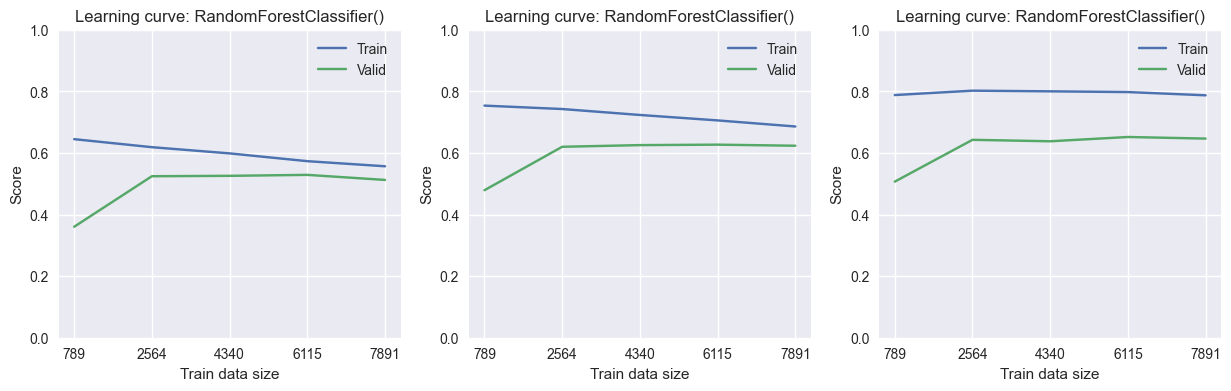

In [34]:
# Создаём объект кросс-валидатора k-fold
skf = model_selection.StratifiedKFold(n_splits=5)

# Визуализируем кривые обучения
fig, axes = plt.subplots(1, 3, figsize=(15, 4)) #фигура + 3 координатных плоскости

# Создаем цикл по списку моделей и индексам этого списка
for i, model in enumerate(models): # i-текущий индекс, model - текущая модель
    plot_learning_curve(
        model=model,
        X=X_train,
        y=y_train,
        cv=skf,
        ax=axes[i],
        title=model.__class__.__name__ + '()'
    )

Из построенных кривых обучения можно сделать вывод, что оптимальной глубиной деревьев является 7 (график по середине), кроме того валидационная метрика на нем выше.

In [44]:
# Создаём модель 2 
best_model = RandomForestClassifier(
    max_depth=7, #максимальная глубина
    min_samples_leaf=5, #минимальное число объектов в лист
    n_estimators=200,
    random_state=42 #генератор случайных чисел 
)

# Обучаем модель на тренировочной выборке
best_model.fit(X_train, y_train)

y_valid_pred = best_model.predict(X_test)

# Выводим значения метрик для валидационной выборки
print('Valid classification_report:\n', metrics.classification_report(y_test, y_valid_pred))

Valid classification_report:
               precision    recall  f1-score   support

       False       0.91      0.98      0.94      2084
        True       0.79      0.49      0.60       382

    accuracy                           0.90      2466
   macro avg       0.85      0.73      0.77      2466
weighted avg       0.89      0.90      0.89      2466



Модель хорошо определяет всех посетителей, которые завершат сессию без покупки, а вот качество распознавания пользователей, совершивших покупку, значительно ниже!

Попробуем повысить качество распознавания посетителей, совершивших покупку. Используем метод подбора порога вероятности с помощью PR-кривой.

Порог вероятности будем подбирать с помощью кросс-валидации.

Сделаем предсказание вероятностей принадлежности к пользователям, которые совершат покупку, на кросс-валидации на пяти фолдах. Используем метод cross_val_predict().

Для кросс-валидации используем случайный лес с подобранной оптимальной максимальной глубиной деревьев, набор данных (параметры X, y) — тренировочная выборка (X_train, y_train).

Построим PR-кривую и отметим на ней точку, в которой наблюдается максимум метрики $F_1$ для посетителей, которые совершат покупку. Определим порог вероятности, соответствующий этой точке.

В качестве ответа приведем значение выбранного порога вероятности.

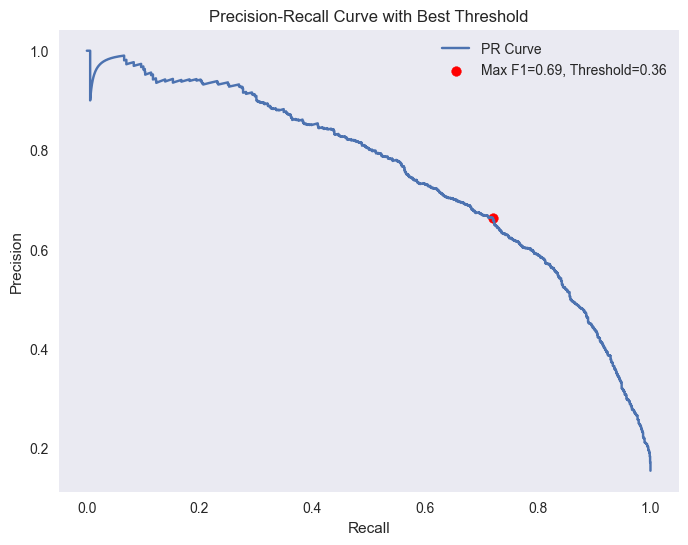

Выбранный порог вероятности: 0.36


In [ ]:
# Создаём модель 2
best_model = RandomForestClassifier(
    max_depth=7, #максимальная глубина
    min_samples_leaf=5, #минимальное число объектов в лист
    n_estimators=200,
    random_state=42 #генератор случайных чисел 
)

# Обучаем модель на тренировочной выборке
best_model.fit(X_train, y_train)

# Создаём объект кросс-валидатора k-fold со стратификацией
skf = model_selection.StratifiedKFold(n_splits=5)
 
# Считаем метрики на кросс-валидации k-fold со стратификацией
y_scores = model_selection.cross_val_predict(
    estimator=best_model, #модель
    X=X_train, #матрица наблюдений X
    y=y_train, #вектор ответов y
    cv=skf, #кросс-валидатор
    method='predict_proba' # предсказания вероятностей
)[:, 1] # Те кто совершат покупку

# Построение PR-кривой
precision, recall, thresholds = metrics.precision_recall_curve(y_train, y_scores)

# Вычисляем F1 для каждого порога
f1_scores = 2 * (precision * recall) / (precision + recall)

# Находим индекс максимума F1
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]  # Порог вероятности
best_f1 = f1_scores[best_index]  # Максимум F1

# Построение графика PR-кривой
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='PR Curve')
plt.scatter(recall[best_index], precision[best_index], color='red', label=f'Max F1={best_f1:.2f}, Threshold={best_threshold:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Best Threshold')
plt.legend()
plt.grid()
plt.show()

# Вывод результата
print(f'Выбранный порог вероятности: {best_threshold:.2f}')

Теперь сделаем предсказание классов объекта с определённым в выше порогом вероятности. Выведем отчёт о метриках классификации.

In [50]:
# Создаём модель 2 
best_model = RandomForestClassifier(
    max_depth=7, # максимальная глубина
    min_samples_leaf=5, # минимальное число объектов в лист
    n_estimators=200,
    random_state=42 #генератор случайных чисел 
)

# Обучаем модель на тренировочной выборке
best_model.fit(X_train, y_train)

# Получение вероятностей для тестовой выборки
y_prob = best_model.predict_proba(X_test)[:, 1]  # Вероятности для класса 1

# Установим нестандартный порог вероятности (например, 0.6)
threshold = 0.36
y_pred_custom = (y_prob >= threshold)

# Вывод отчёта о метриках
print(metrics.classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

       False       0.94      0.93      0.94      2084
        True       0.66      0.69      0.67       382

    accuracy                           0.90      2466
   macro avg       0.80      0.81      0.81      2466
weighted avg       0.90      0.90      0.90      2466



Вывод: Благодаря подбору порога вероятности удалось повысить охват (recall) посетителей, которые совершат покупку, за счёт чего выросло значение $F_1$-score.